In [1]:
import sys
import os

sys.path.append(os.path.abspath('D:\ITC\РНФ_Курганский_2024\pythonProject\MarS'))

import numpy as np
import torch
from torch import nn
import math
import pathlib

from scipy.spatial import Delaunay
import matplotlib.pyplot as plt
from importlib import reload
import pandas as pd

import mars
from mars import res_field_algorithm
from mars import spin_model
from mars import save_procedures

from mars import particles, spin_model, spectra_manager
from mars import optimization

Some stuff might fail: issue in joblib
[KeOps] Warning : No C++ compiler found. Define CXX environment variable or install g++.
[KeOps] Warning : No C++ compiler found. You need to either define the CXX environment variable pointing to a valid compiler, or ensure that 'g++' is installed and in your PATH.
[KeOps] Warning : CUDA libraries not found or could not be loaded; Switching to CPU only.
[KeOps] Warning : No C++ compiler found. You need to either define the CXX environment variable pointing to a valid compiler, or ensure that 'g++' is installed and in your PATH.
[KeOps] Warning : No C++ compiler available to check for OpenMP support.
[KeOps] Warning : OpenMP support is not available. Disabling OpenMP.


In [2]:
import contexter, experemental_data_getter, profiler, sample_getter

In [3]:
dtype = torch.float64
device = torch.device("cpu")
b1_field = 1.0 * 1e-6
freq = 9.67 * 1e9

In [4]:
def get_sample_triplet(params, dtype: torch.dtype = torch.float32, device: torch.device = torch.device("cpu")) ->\
        spin_model.MultiOrientedSample:
    g_factor, D, E, h_strain, gauss, lorentz =\
        params["g_factor"], params["D"], params["E"], params["h_strain"], params["gauss"], params["lorentz"]

    zeem = spin_model.Interaction(g_factor, dtype=dtype, device=device)

    D_val = D
    E_val = E

    ee_int = spin_model.DEInteraction((D_val, E_val), dtype=dtype, device=device)

    system = spin_model.SpinSystem(
        electrons=[1.0],
        g_tensors=[zeem],
        electron_electron=[(0, 0, ee_int)],
        dtype=dtype, device=device
    )
    return spin_model.MultiOrientedSample(system, h_strain, gauss, lorentz, mesh=(15, 15), dtype=dtype, device=device)

In [5]:
params = {'g_factor': 2.0062566367854773,
 'D': 90217300.40595116,
 'E': 30083617.12040935,
 'lorentz': 0.0007068854625226938,
  'gauss': 0.0,
 'h_strain': 29094138.27713324}
sample_dirad = sample_getter.get_sample(params, dtype=dtype, device=device)
sample_triplet = get_sample_triplet(params, dtype=dtype, device=device)

### Check that ZFS and Dipolar give the same relaxation dependacne

In [6]:
dipolar = mars.spin_model.DEInteraction([0.0, 1.0], device=device, dtype=dtype).tensor
zfs = mars.spin_model.DEInteraction([0.0, 1.0], device=device, dtype=dtype).tensor

_density_function = contexter._get_density_fanction(device, dtype)

dipolar = sample_dirad.get_oriented_electron_electron_interaction(dipolar, 0, 1)
zfs = sample_triplet.get_oriented_electron_electron_interaction(zfs, 0, 0)

In [7]:
zfs.shape

torch.Size([107, 3, 3])

In [8]:
dipolar = [(dipolar, torch.zeros_like(dipolar))]
zfs = [(zfs, torch.zeros_like(zfs))]

In [9]:
red_channel_dipolar = mars.population.RedfieldRelaxationChannel(
        dipolar, _density_function, thermal_balance_mode="symmetric")
red_channel_zfs = mars.population.RedfieldRelaxationChannel(
        zfs, _density_function, thermal_balance_mode="symmetric")

In [10]:
red_channel_zfs

RedfieldRelaxationChannel(
thermal_balance_mode=symmetric, 
secular=Not Initialized, 
eigen_basis=None, 
num_operators=1, 
spectral_density_func=_density_function) 

In [11]:
context_zfs = mars.population.Context(basis="product",
    sample=sample_triplet, relaxation_coupling_channels=[red_channel_zfs], device=device, dtype=dtype
)
context_dirad = mars.population.Context(basis="product",
    sample=sample_dirad, relaxation_coupling_channels=[red_channel_dipolar], device=device, dtype=dtype
)

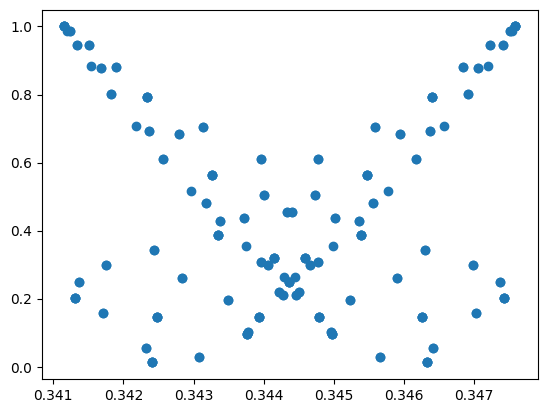

In [18]:
T1_fields = torch.linspace(0.25, 0.4, 1000, dtype=dtype, device=device)
res_fields, kinetic_coeffs = mars.visualization.analysis.relaxation_field_dep(context_dirad, sample_dirad, freq=freq, temperature=4.0, fields=T1_fields, levels_pair=(1, 3), )
plt.scatter(res_fields.flatten(), kinetic_coeffs.flatten())

In [13]:
context_zfs.spin_system_dim

3

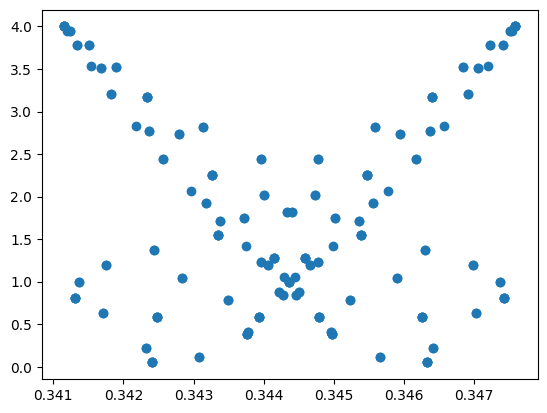

In [19]:
T1_fields = torch.linspace(0.25, 0.4, 1000, dtype=dtype, device=device)
res_fields, kinetic_coeffs = mars.visualization.analysis.relaxation_field_dep(context_zfs, sample_triplet, freq=freq, temperature=4.0, fields=T1_fields, levels_pair=(0, 2), )
plt.scatter(res_fields.flatten(), kinetic_coeffs.flatten())